In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
def batch_muon_directions(rng,N): # genera la dirección en la que se mueven N muones
    directions = np.empty((N,3))
    filled = 0
    while filled < N: # rejection sampling para el cos^2 con theta
        size = 2*(N-filled) # hace siempre el doble porque ese cómputo es menos costoso que repetir el loop
        theta = rng.uniform(0,np.pi/2,size)
        accept = rng.uniform(0,1,size) < np.cos(theta)**2 # chequea todos de una, más rápido
        theta = theta[accept]

        signo = rng.integers(0,2,len(theta))
        #phi = rng.uniform(0,2*np.pi,len(theta)) # samplea phi de una uniforme
        phi = np.pi/2 + np.pi*signo
        sin_theta = np.sin(theta) # lo calculo una sola vez en lugar de 2
        new_dirs = np.stack([
            sin_theta*np.cos(phi),
            sin_theta*np.sin(phi),
            -np.cos(theta) # el vector apunta para el piso
        ],axis=1)
        
        to_add = min(N-filled,len(new_dirs)) # agrega las direcciones necesarias
        directions[filled:filled+to_add] = new_dirs[:to_add]
        filled += to_add
    
    return directions

def batch_generate_muon_t(det_size,det_delta,det_height,margin,rate,rng,N):
    x_length = det_size # la longitud del plano en la dirección en la que no roto es el lado de los centelladores
    y_length = det_delta+2*det_height+2*margin # en la dirección en la que roto es la longitud ocupada por los centelladores
                                               # (distancia + alturas) sumando un margen a elección
    area = x_length*y_length
    
    ts = rng.exponential(scale=1/(rate*area),size=N) # sampleo el tiempo entre muones de una exponencial
    
    x_o = rng.uniform(-x_length/2,x_length/2,size=N)
    y_o = rng.uniform(-y_length/2,y_length/2,size=N)
    z_o = np.full(N,det_height+det_delta/2) # la altura de generación es el punto medio entre los centelladores
    starts = np.stack([x_o,y_o,z_o],axis=1) 

    flechas = batch_muon_directions(rng,N)
    return ts,starts,flechas

def generar_lluvia(mode,det_size,det_delta,det_height,margin,seed=0,rate=1/60,t_f=0,n=0,buffer_extra=1000):
    rng = np.random.default_rng(seed) # defino el generador de números aleatorios

    if mode == 'n':  # si quiero un número de muones fijo
        ts,muon_starts,muon_flechas = batch_generate_muon_t(det_size,det_delta,det_height,margin,rate,rng,n)
        muon_times = np.cumsum(ts)

    # ACLARACIÓN: EL MODO TEMPORAL PUEDE GENERAR UN TIEMPO MENOR AL PEDIDO, PERO ES LA MANERA DE HACERLO EFICIENTE
    # SE PUEDE AUMENTAR EL buffer_extra PARA MEJORARLO PERO LA FORMA DE HACERLO CORRECTAMENTE ES CON UN LOOP MUY INEFICIENTE
    elif mode == 't':  # si quiero un tiempo de simulación fijo
        buffer_size = int(rate*det_size*(det_delta+2*det_height+2*margin)*t_f)+buffer_extra
        # sobresampleo para intentar tener suficientes
        ts,starts,flechas = batch_generate_muon_t(det_size,det_delta,det_height,margin,rate,rng,buffer_size)
        cum_ts = np.cumsum(ts)
        valid = cum_ts < t_f

        muon_times = cum_ts[valid]
        muon_starts = starts[valid]
        muon_flechas = flechas[valid]

    else:
        raise ValueError("Modo incorrecto: use 'n' (número) o 't' (tiempo)")

    return muon_times,muon_starts,muon_flechas

def rotate_x(element,angle): # rota un elemento (nos va a interesar el centro de los cuadrados del detector) en un ángulo
                             # alrededor del eje x
    sen = np.sin(angle)
    cos = np.cos(angle)

    x,y,z = element.T
    rotated = np.stack([x,cos*y-sen*z,sen*y+cos*z],axis=-1)
    return rotated # calcula la matriz de rotación y se la aplica al vector (que tiene que ser un array) sin tener que pasar
                   # por el producto matricial

normal_angle = lambda ang : np.array([0.0,np.sin(ang),np.cos(ang)]) # genera el vector normal al cuadrado de los detectores
                                                                    # dado que rotaron un cierto ángulo desde la posición
                                                                    # vertical

def ray_plane_intersection(start,flecha,center,normal): # calcula el punto en el que la traza de un muón intersecta el plano
                                                        # que contiene a algún cuadrado de los detectores
    denom = np.dot(normal,flecha)
    
    if np.abs(denom) < 1e-6: # evita casos límites que son complicados numéricamente
        return None
    
    t = np.dot(normal,center-start)/denom # la distancia recorrida desde el punto start hasta el de intersección
    return start+t*flecha # devuelve el punto en el que ocurre la intersección

def calc_uv(normal): # calcula unos vectores de proyecciones que sirven para ver si un punto está adentro del cuadrado
    u = np.cross(normal,np.array([0,0,1]))
    if np.linalg.norm(u) < 1e-6:
        u = np.cross(normal,np.array([0,1,0]))
    u = u/np.linalg.norm(u)
    v = np.cross(normal,u)
    return u,v

def is_point_in_square(point,center,normal,u,v,half_len):
    local_point = point - center
    u_dist = np.dot(local_point,u)
    v_dist = np.dot(local_point,v)

    epsilon = 1e-10
    return (-half_len - epsilon <= u_dist <= half_len + epsilon) and (-half_len - epsilon <= v_dist <= half_len + epsilon)

def intersect_square(start,flecha,center,normal,u,v,half_len):
    point = ray_plane_intersection(start,flecha,center,normal)
    if point is None:
        return False
    return is_point_in_square(point,center,normal,u,v,half_len)

def intersect_detector(start,flecha,center_top,center_bottom,normal,u,v,half_len):
    top_intersection = intersect_square(start,flecha,center_top,normal,u,v,half_len)
    bottom_intersection = intersect_square(start,flecha,center_bottom,normal,u,v,half_len)
    return top_intersection or bottom_intersection

def sim_rotados(lluvia,det_size,det_height,det_xy,det_delta,freq,seed=0):
    rng = np.random.default_rng(seed) # defino el generador de números aleatorios

    ang0 = rng.uniform(0,2*np.pi) # calculo el ángulo en el que se encuentra el par de centelladores respecto al eje z
    center_top = np.array([*det_xy,det_delta + det_height])
    center_top_up = center_top + np.array([0,0,det_height])
    center_bottom = center_top - np.array([0,0,det_delta])
    center_bottom_down = center_bottom - np.array([0,0,det_height])
    # defino el centro de los cuadrados de cada cara (superior e inferior) de cada centellador
    
    measured_angles = []
    times,starts,flechas = lluvia

    for t,start,flecha in zip(times,starts,flechas):
        ang = (np.pi*freq*t+ang0)%(2*np.pi)
        
        normal_new = normal_angle(ang) # calculo la nueva normal, la misma para todos los cuadrados
        u,v = calc_uv(normal_new) # calculo las proyecciones necesarias para las intersecciones

        # roto los centros del primer detector
        center_top_new = rotate_x(center_top,ang)
        center_top_up_new = rotate_x(center_top_up,ang)

        if intersect_detector(start,flecha,center_top_up_new,center_top_new,normal_new,u,v,det_size/2):
            # si pasó por el primer detector, roto los centros del segundo (no es necesario chequear los que ya no pasan por
            # el primero porque no se cuentan como detecciones si no pasan por ambos)
            center_bottom_new = rotate_x(center_bottom,ang)
            center_bottom_down_new = rotate_x(center_bottom_down,ang)
            if intersect_detector(start,flecha,center_bottom_new,center_bottom_down_new,normal_new,u,v,det_size/2):
                measured_angles.append(ang)
                # si pasaron por ambos detectores, registro el ángulo en el que fueron detectados)

    return measured_angles,len(times)


In [15]:
angles = data[1:]
len(angles)

398

In [16]:
def transform_angles(angs):
    new_angs = angs % np.pi
    new_angs = np.where(new_angs > np.pi/2, np.pi - new_angs,new_angs)
    new_angs = np.degrees(new_angs)
    return new_angs

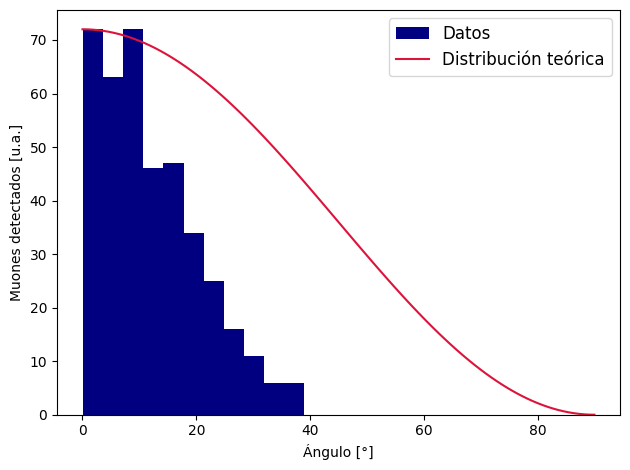

In [20]:
modified_angles = transform_angles(angles)

n,bins,_ = plt.hist(np.array(modified_angles),bins=11,color='navy',density=False,label='Datos')
#plt.axvline(np.pi,color='crimson',ls='--')
x = bins[:-1] + np.diff(bins)/2
x = np.linspace(0,90,100)
plt.plot(x,np.max(n)*np.cos(np.radians(x))**2,c='crimson',label='Distribución teórica')
plt.legend(fontsize=12)
plt.ylabel('Muones detectados [u.a.]')
plt.xlabel('Ángulo [°]')
plt.tight_layout()

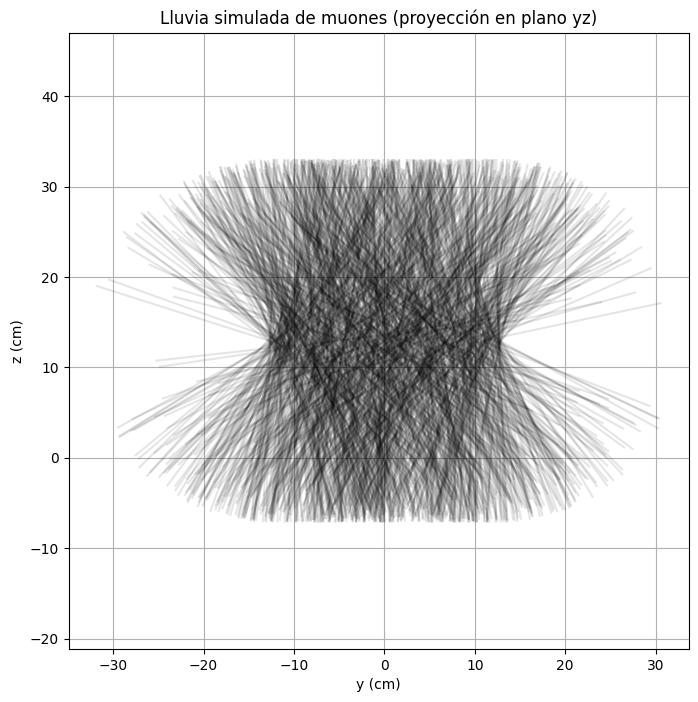

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_lluvia_muones_2D(starts, directions, largo=5):
    """
    Proyecta en el plano yz las trayectorias de los muones.
    """
    plt.figure(figsize=(8, 8))

    for start, d in zip(starts, directions):
        y0, z0 = start[1], start[2]
        dy, dz = d[1], d[2]

        # Extiende la recta en ambas direcciones
        y1, z1 = y0 - largo * dy, z0 - largo * dz
        y2, z2 = y0 + largo * dy, z0 + largo * dz

        plt.plot([y1, y2], [z1, z2], color='black', alpha=0.1)

    plt.xlabel('y (cm)')
    plt.ylabel('z (cm)')
    plt.title('Lluvia simulada de muones (proyección en plano yz)')
    plt.grid(True)
    plt.axis('equal')
    plt.show()
# Parámetros del detector
det_size = 4        # cm
det_delta = 23.7        # cm (distancia entre detectores)
det_height = 1.1      # cm (altura del detector)
margin = 0         # margen de generación en y
rate = 1/60           # tasa de muones/cm²/s
N = 1000            # cantidad de muones a generar

rng = np.random.default_rng(seed=42)
ts, starts, directions = batch_generate_muon_t(det_size, det_delta, det_height, margin, rate, rng, N)

graficar_lluvia_muones_2D(starts, directions, largo=20)


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def rotar_xy(puntos, ang):
    """Rota una lista de puntos en el plano XY respecto al origen."""
    R = np.array([
        [np.cos(ang), -np.sin(ang), 0],
        [np.sin(ang),  np.cos(ang), 0],
        [0, 0, 1]
    ])
    return puntos @ R.T

def graficar_detectores_rotados(det_size, det_height, det_delta, det_xy, seed=0):
    rng = np.random.default_rng(seed)
    ang0 = rng.uniform(0, 2*np.pi)

    # Centro del plano superior y del inferior
    center_top = np.array([*det_xy, det_delta + det_height])
    center_top_up = center_top + np.array([0, 0, det_height])
    center_bottom = center_top - np.array([0, 0, det_delta])
    center_bottom_down = center_bottom - np.array([0, 0, det_height])

    # Función para construir un plano rectangular
    def construir_plano(center):
        x, y, z = center
        dx = det_size / 2
        dy = det_size / 2
        esquinas = np.array([
            [-dx, -dy, 0],
            [-dx,  dy, 0],
            [ dx,  dy, 0],
            [ dx, -dy, 0]
        ])
        rotadas = rotar_xy(esquinas, ang0)
        return rotadas + center

    planos = [
        construir_plano(center_top_up),
        construir_plano(center_top),
        construir_plano(center_bottom),
        construir_plano(center_bottom_down)
    ]

    colores = ['red', 'orange', 'blue', 'cyan']

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')

    for plano, color in zip(planos, colores):
        coleccion = Poly3DCollection([plano], alpha=0.5, color=color)
        ax.add_collection3d(coleccion)

    # Dibujar eje central
    ax.scatter(*center_top, color='black', s=50, label='Centro Top')
    ax.scatter(*center_bottom, color='gray', s=50, label='Centro Bottom')

    # Límites del gráfico
    L = det_size
    ax.set_xlim(det_xy[0]-L, det_xy[0]+L)
    ax.set_ylim(det_xy[1]-L, det_xy[1]+L)
    ax.set_zlim(0, det_delta + 3*det_height)

    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')
    ax.set_zlabel('Z (cm)')
    ax.set_title('Detectores rotados en 3D')
    ax.legend()
    plt.tight_layout()
    plt.show()


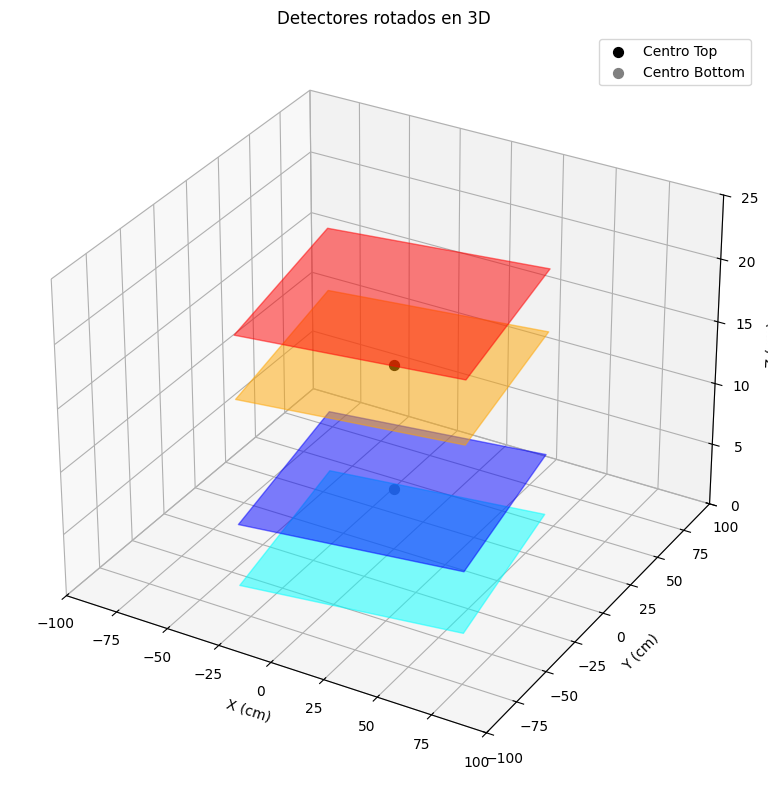

In [34]:
graficar_detectores_rotados(
    det_size=100,
    det_height=5,
    det_delta=10,
    det_xy=(0, 0),
    seed=42
)